In [1]:
import numpy as np
import pandas as pd
import random
import itertools
import base64
import uuid
import copy
from types import CellType
from enum import StrEnum
from datetime import datetime

In [2]:
!pip install faker

In [3]:
from faker import Faker

In [4]:
SEED = 500
random.seed(SEED) #For reproducibility (although datamimic_ce has its own random generator / seed)
rng = np.random.default_rng(seed=SEED)
Faker.seed(SEED)

In [5]:
#Create deterministic User model that will interact with the App environment, generating actions (either UserActions or PaymentActions)
#according to some simple probabilistic constrains. The result of the interaction of the User model with the App environment is a DataFrame
#with temporal recordings

#Sources:
#https://research.atspotify.com/2023/07/automatic-music-playlist-generation-via-simulation-based-reinforcement-learning
#https://towardsdatascience.com/introduction-to-embedding-based-recommender-systems-956faceb1919/

In [6]:
class PaymentActions(StrEnum):
    PAYMENT_EXPRESS = "Payment_express"
    SERVICE_PAYMENT = "Service_payment"
    CREDITCARD_PAYMENT = "CreditCard_payment"
    INTERBANK_PAYMENT = "Interbank_payment"
    #BENEF_PAYMENT = "Benef_payment"
    BENEF_INTERBANK_PAYMENT = "Benef_interbank_payment"
    OWN_TRANSFERS = "Own_transfers"
    #DEPOSIT = "Deposit"

class UserActions(StrEnum):
    DASHBOARD = "Dashboard"
    ACCOUNT_DETAILS = "Account_Details"
    TRANS_HISTORICAL = "Transaction_Historical"

class AccountTypes(StrEnum):
    CHECKING = "CHECKING"
    SAVINGS = "SAVINGS"
    MONEYMARKET = "MONEY_MARKET",
    CERTIFICATE_OF_DEPOSIT = "CERTIFICATE_OF_DEPOSIT"

class AccountBalanceStatus(StrEnum):
    NEGATIVE = "NEGATIVE"
    POSITIVE = "POSITIVE"
    FLAT = "FLAT"

#TODO: change destiny_accounts values to be unique ints representing account numbers
destiny_accounts = {
    "SERVICE_PAYMENT": ["PHONE", "NETFLIX", "ELECTRICITY", "INTERNET", "WATER"],
    "PAYMENT_EXPRESS":["PURCHASES"],
    "BENEF_INTERBANK_PAYMENT": ["RENT", "FINANCIAMIENTO"],
}

destiny_accounts_amounts = {
    "SERVICE_PAYMENT": {
        "PHONE": {"mean": 1500.00, "deviation": 20.00},
        "NETFLIX": {"mean": 600.00, "deviation": 0.00},
        "ELECTRICITY": {"mean": 3000.00, "deviation": 1000.00},
        "INTERNET": {"mean": 2400.00, "deviation": 0.00},
        "WATER": {"mean": 300.00, "deviation": 100.00}
    },
    "PAYMENT_EXPRESS": {
        "PURCHASES": {"mean": 5500.00, "deviation": 2000.00}
    },
    "BENEF_INTERBANK_PAYMENT": {
        "RENT": {"mean": 10000.00, "deviation": 0.00},
        "FINANCIAMIENTO": {"mean": 8000.00, "deviation":300.00}
    }
}

destiny_amounts_express = {
    "PURCHASES": 3500.00
}

destiny_accounts_interbank = {
    "RENT": 10000.00,
    "FINANCIAMIENTO": 10000.00
}

In [7]:
'''
Constants
'''
MIN_ACCNT_BALANCE = 0
MAX_ACCNT_BALANCE = 1000000
MAX_NUMBER_OF_ACCOUNTS = 5
USER_MONTHLY_INCOME = 25000.00
#Define the window of time in days when the user usually gets wage payment
FIRST_HALF_PAYDAYS = [13, 14, 15, 16]
SECOND_HALF_PAYDAYS = [27, 28, 29, 30]
#The percentage of the time that will be assigned to login the days defined by FIRST_HALF_PAYDAYS and SECOND_HALF_PAYDAYS.
#The actual value is randomly picked between PAYDAYS_WEIGHT_INTERVALS[0] and PAYDAYS_WEIGHT_INTERVALS[1]
PAYDAYS_WEIGHT_INTERVALS = [0.45, 0.65]
MAX_NUMBER_OF_INACTIVITY_DAYS = 10

In [8]:
#Helper function to obtain a True value with a p probability
def chance(p = 0.5):
    return rng.choice([True, False], p=[p, 1-p])

#Obtain a random payment amount within the [mean-deviation, mean+deviation] range
def amount_by_chance(mean, deviation):
    sign = rng.choice([-1, 1])
    if deviation == 0:
        return mean
    return mean+sign*rng.choice(int(deviation))

#Generate a sessionId to attach a set of actions to that session
def generate_session_id():
    return str(uuid.uuid4())

#Randomly pick a wage payment day with equaly distributed probabilities
def get_payday(p = [0.25, 0.25, 0.25, 0.25], days=['13', '14', '15', '16']):
    return rng.choice(days, p=p)


In [9]:
'''
Account object abstraction

'''

class Account():
    def __init__(self, account_type=None, account_number=None, balance=None):
        self.account_type = AccountTypes.SAVINGS if account_type is None else account_type
        self.account_number = self.generate_short_uuid() if account_number is None else account_number
        self.balance = np.random.randint(MIN_ACCNT_BALANCE, MAX_ACCNT_BALANCE) if balance is None else balance

    def __str__(self):
        return f"Account(account_type={self.account_type}, account_number={self.account_number}, balance={self.balance})"

    def generate_short_uuid(self):
        # 1. Generate a standard random 128-bit UUID
        raw_uuid = uuid.uuid4()

        # 2. Encode the raw 16 bytes into URL-safe Base64
        base64_bytes = base64.urlsafe_b64encode(raw_uuid.bytes)

        # 3. Convert to string and remove the trailing "==" padding
        return base64_bytes.decode('utf-8')#.rstrip('==')


In [10]:
'''
User object abstraction
TODO: properly handle the validation and exception handling for non Account objects passed to set_accounts
'''

class User():
    def __init__(self):
        self.account_list = np.empty((MAX_NUMBER_OF_ACCOUNTS, ), dtype=object)
        self.monthly_income = USER_MONTHLY_INCOME
        self.pending_payment_actions = copy.deepcopy(destiny_accounts)
        self.destiny_accounts_amounts = copy.deepcopy(destiny_accounts_amounts)
        self.wage_received = False
        self.payment_track = []

    def __str__(self):
        return f"User(account_list={self.account_list})"

    '''
    Return the first account in self.account_list that matches the provided account_type
    '''
    def get_account_number(self, account_type):
        if account_type not in [type.name for type in AccountTypes]:
            raise ValueError(f"Invalid account type: {account_type}")
        return [acc.account_number for acc in self.account_list if acc.account_type==account_type][0]

    '''
    Helper function that returns a randomly picked payment type, payment action and due payment amount. The conditional
    probability for the action depends on the current day-of-the-month (dom), if wage payment
    was already done for the biweekly period and the quantity of payments already processed in the ongoing month.
    '''
    def get_next_action(self, dom=1):
        # Damp the probability of a payment if the user has not received any payment just yet
        # to emulate a more likely payment of services and debt after receiving the salary
        #   With p certainty, (if no salary payment recieved) no next payment action is done
        if not self.wage_received and chance(p=0.985):
            print("[INFO] returning empty due to wage not received")
            return ("", 0.00)
        # Increase likelyness of next payment action if dom is within the biweekly window
        # TODO calculate prob of payment happening according to how close it is to the mean of the paydays list (z-score)
        if dom not in FIRST_HALF_PAYDAYS+SECOND_HALF_PAYDAYS and chance(p=0.985):
            print("[INFO] returning empty due to dow not in window")
            return ("", 0.00)

        # Reduce the probability of performing all payments in the same day
        payments_count = self.payment_track.count(dom)
        #Avoid dividing by zero
        if payments_count > 1:
            recurrent_payment_probability = (1/payments_count)
            if chance(p=recurrent_payment_probability):
                print("[INFO] returning empty due to high number of payments already made on same day")
                return ("", 0.00)
        # Obtain pending payment types
        try:
            payments = list(self.pending_payment_actions.keys())
            if (payments==[]):
                self.payment_track = []
                print("[INFO] returning empty due to no pending payments")
                return ("", 0.00)

            if len(payments) >= 1:
                #Assing the same probability to performing any of the pending actions
                probabilities = [1/len(payments)]*len(payments)
                payment_type = rng.choice(payments, p=probabilities)
                #From the picked payment action type, choose also a subtype
                next_possible_actions = self.pending_payment_actions[payment_type]
                probabilities = [1/len(next_possible_actions)]*len(next_possible_actions)
                next_action = rng.choice(next_possible_actions, p=probabilities)
                #Get due payment
                payment_configuration = self.destiny_accounts_amounts[payment_type][next_action]
                due_amount = amount_by_chance(mean=payment_configuration["mean"], deviation=payment_configuration["deviation"])
                print(f"[INFO] chosen next-payment-action: {payment_type}:{next_action}")
                print(f"[INFO] due amount: {due_amount}")
                #global payment_track
                self.payment_track.append(dom)
                #remove payment_type/next_action from pending_payment_actions
                if len(self.pending_payment_actions[payment_type]) == 1:
                    self.pending_payment_actions.pop(payment_type)
                else:
                    self.pending_payment_actions[payment_type].remove(next_action)
                return (payment_type+":"+next_action, due_amount)
        except AttributeError:
            print(f"[INFO] No pending payment actions were able to be extracted")
            return ("", 0.00)

    def _init_states(self):
        #Clean up instance variables to emulate the start of a new month
        self.pending_payment_actions = copy.deepcopy(destiny_accounts)
        self.destiny_accounts_amounts = copy.deepcopy(destiny_accounts_amounts)
        self.wage_received = False
        self.payment_track = []

    def set_accounts(self, account_list):
        self.account_list = account_list[:MAX_NUMBER_OF_ACCOUNTS]
        return self.account_list

    def get_accounts(self):
        return self.account_list

    #Get total sum of available balances for all accounts
    def get_balances(self):
        total = 0
        #Get total balance for SAVING, CHECKING and CERTIFICATE_OF_DEPOSIT
        for account in self.get_accounts():
            total+=account.balance
        #Substract any pending balance from credit card entity
        #total -= credit_card.current_balance
        return total

    #SAVINGS account related getter/setter functions
    #TODO: overload the functions to be able to handle other AccountTypes and to specify the target acccount by account_number
    def get_balance(self):
        for account in self.account_list:
            if account.account_type == AccountTypes.SAVINGS:
                return account.balance
        return None

    def set_balance(self, balance):
        #Get the index of the first Savings accounts
        account_index = [indx for indx, accnt in np.ndenumerate(self.account_list) if accnt.account_type == AccountTypes.SAVINGS][0]
        self.account_list[account_index].balance += balance
        return self.account_list[account_index].balance


In [11]:
#Instantiate User object and create accounts. Initially assign one account for each type defined in AccountTypes
user = User()
user.account_list=np.array([Account(account_type=type.name) for type in AccountTypes])
user.__str__()

'User(account_list=[<__main__.Account object at 0x7c5c920a3d40>\n <__main__.Account object at 0x7c5c9868eba0>\n <__main__.Account object at 0x7c5c920a3ce0>\n <__main__.Account object at 0x7c5c920a3e00>])'

In [12]:
print(f"User SAVINGS account balance before simulated deposit: {user.get_balance()}")

User SAVINGS account balance before simulated deposit: 935692


In [13]:
print(f"User SAVINGS account balance after simulated deposit: {user.set_balance(3000)}")

User SAVINGS account balance after simulated deposit: 938692


In [14]:
print(f"Sum of total user account balances: {user.get_balances()}")

Sum of total user account balances: 2364225


In [15]:
print(f"User SAVINGS account number: {user.get_account_number(AccountTypes.SAVINGS)}")

User SAVINGS account number: dqUy7gI2Q0axcw65lBEyUg==


In [16]:
fake = Faker()
'''
Returns a sorted list of number_of_dates dates randomly generated for the year and month given
'''
def generate_dates(number_of_dates=250, year=2025, month=1):
    # Determine the last_day in the month to avoid ValueError scenarios with DateTimeGenerator
    match month:
        case 1 | 3 | 5 | 7 | 8 | 10 | 12:
            last_day = 31
        case 4 | 6 | 9 | 11:
            last_day = 30
        case 2:
            last_day = 28
    # Generate the days progression spaces for the two wage payment windows and the rest of the month
    # The idea here is to assign a greater amount of dates (and login events) to the by-weekly windows defined in FIRST_HALF_PAYDAYS and SECOND_HALF_PAYDAYS
    paydays_proportion = rng.choice(np.linspace(PAYDAYS_WEIGHT_INTERVALS[0], PAYDAYS_WEIGHT_INTERVALS[1], num=10))
    number_of_payday_dates = int(paydays_proportion*number_of_dates)
    number_of_remaining_dates = number_of_dates-number_of_payday_dates
    first_period_dates = np.linspace(1, FIRST_HALF_PAYDAYS[0], num=int(number_of_remaining_dates/2), dtype=np.int32)
    second_period_dates = np.linspace(FIRST_HALF_PAYDAYS[0]+1, FIRST_HALF_PAYDAYS[1], num=int(number_of_payday_dates/2), dtype=np.int32)
    third_period_dates = np.linspace(FIRST_HALF_PAYDAYS[1]+1, SECOND_HALF_PAYDAYS[0], num=int(number_of_remaining_dates/2), dtype=np.int32)
    fourth_period_dates = np.linspace(SECOND_HALF_PAYDAYS[0]+1, last_day, num=int(number_of_payday_dates/2), dtype=np.int32)
    dates = np.concatenate((first_period_dates, second_period_dates, third_period_dates, fourth_period_dates))
    #Ramdonly remove up to MAX_NUMBER_OF_INACTIVITY_DAYS from the dates pool to simulate user inactivity (no logins)
    number_of_dates_to_remove = rng.choice(np.arange(MAX_NUMBER_OF_INACTIVITY_DAYS))
    print(f"[INFO] number_of_dates_to_remove: {number_of_dates_to_remove}")
    dates_to_remove = rng.choice(np.arange(last_day), size=number_of_dates_to_remove)
    dates = np.delete(dates, np.where(np.isin(dates, dates_to_remove)))

    # Deterministic dates within the min-max period.
    synthetic_dates = []

    # for each date in dates pick a random timestamp between the beginning of day (00:00:00) and the end of the day (23:59:59)
    for date in dates:
        begin_of_day_date = datetime(year=year, month=month, day=date, hour=00, minute=00)
        end_of_day_date = datetime(year=year, month=month, day=date, hour=23, minute=59)
        synthetic_dates.append(fake.date_time_between(start_date=begin_of_day_date, end_date=end_of_day_date))

    synthetic_dates.sort()
    return synthetic_dates

In [17]:
# Generate number_of_dates within the min-max window. Each date will be related
#to an specific user action (transactional or not)

#TODO: handle all list datasets more efficiently in one common DataFrame
dates = []
user_actions = []
session_ids = []
balance = []

#Number of years and months to span
YEARS_SPAN = 2
FIRST_YEAR = 2024
years = [FIRST_YEAR+year for year in range(YEARS_SPAN)]
months = [month for month in range(1, 13)]


dates = []

#The list with all payment/non-payment user_actions
user_actions = []

#The list with all uuid's that identify a session
session_ids = []

#The list of total balances registered for each state/user-action
balances = []#[getBalances()]*len(dates)

#The registry of the source accounts for the payments
accounts_from = []

#The historical track for the main account balance
main_savings_balance = []

#The historical track for the main account balance
main_checking_balance = []

#The balance status for the main savings account
main_savings_balance_status = []

#The balance status for the main checking account
main_checking_balance_status = []

payment_flags = []

'''
Populates the list of user_actions generated by the user entity while it interacts with the
App environment in the span of time defined by the years constant
'''
def generate_user_actions(user: User):

    #generate monthly set of dates and transactions for given list of years
    for year, month in list(itertools.product(years, months)):
        #Initialice user's context variables for new iteration
        user._init_states()

        print(f"[INFO] iterating for year {year} and month {month}")

        #Randomly generate the date stamps for the current month and year
        monthly_dates = generate_dates(year=year, month=month)

        #Initialize the lists with the montly params with static data (it will be updated later)
        monthly_user_actions = [UserActions.DASHBOARD]*len(monthly_dates)
        monthly_session_ids = [generate_session_id() for n in range(len(monthly_dates))]
        daily_balances = [user.get_balances()]*len(monthly_dates)
        #TODO: Diversify the payments configurations by properly inserting valid account_number's
        #from the user's accounts arrangement into payment_accounts_from
        payment_accounts_from = [user.get_account_number(AccountTypes.SAVINGS)]*len(monthly_dates)
        main_account_balances = [0]*len(monthly_dates)
        main_savings_status = [AccountBalanceStatus.FLAT]*len(monthly_dates)
        payment_due = [False]*len(monthly_dates)

        #Randomly pick a payment day for each payment period
        payday1 = get_payday(days=FIRST_HALF_PAYDAYS)
        payday2 = get_payday(days=SECOND_HALF_PAYDAYS)
        print(f"[INFO] Paydays: {payday1} and {payday2}")
        first_payment_received = False
        second_payment_received = False

        #Emulate user interaction with the environment at the iterated date and session
        i = 0 #i keeps the index for the current session, it will be also used to modify both past sessions [i-1] and future sessions [i+1]
        for date in monthly_dates:
            #Generate a session date and its sessionId
            #TODO:
            # -Encapsulate all the following logic in a function,
            # -evaluate increment in seconds
            #date = monthly_dates[i]
            user_action = monthly_user_actions[i]
            session_id = monthly_session_ids[i]
            #print("[INFO] user interacting with user_action:", user_action)

            #Emulate a wage payment to the users SAVINGS account
            if date.day >= int(payday1) and not user.wage_received:
                print(f"[INFO] Registering first wage payment of the month on day: {date.day}")
                balance = user.set_balance(USER_MONTHLY_INCOME)
                print(f"[INFO] Updated SAVINGS balance: {balance}")
                user.wage_received = True

            #Obtain accounts balances previous to any transaction on the session
            total_balace = user.get_balances()
            current_savings_balance = user.get_balance()
            previous_savings_balance = main_account_balances[i-1]
            #Update account_status according to changes in the balance
            if previous_savings_balance < current_savings_balance:
                account_status = AccountBalanceStatus.POSITIVE
            elif previous_savings_balance == current_savings_balance:
                account_status = AccountBalanceStatus.FLAT
            else:
                account_status = AccountBalanceStatus.NEGATIVE
            #Update balances lists for current epoch
            daily_balances[i] = total_balace
            main_account_balances[i] = current_savings_balance
            main_savings_status[i] = account_status
            payment_accounts_from[i] = user.get_account_number(AccountTypes.SAVINGS)
            #print("[INFO] total_balaces:", total_balaces)

            #Insert AccountDetails action within the next random number of minutes with p probability
            if chance(p=0.55) == True and user_action == UserActions.DASHBOARD:
              #print(f"[INFO] state transitioning to acc-details user_action")
              next_minute = random.randint(date.minute, 59)
              date = date.replace(minute=next_minute)
              #print(f"[INFO] date after summing {next_minute} mins:", date)
              monthly_dates.insert(i+1, date)
              monthly_user_actions.insert(i+1, UserActions.ACCOUNT_DETAILS)
              daily_balances.insert(i+1, total_balace)
              main_account_balances.insert(i+1, current_savings_balance)
              main_savings_status.insert(i+1, account_status)
              payment_accounts_from.insert(i+1, user.get_account_number(AccountTypes.SAVINGS))

              #Avoid duplicating session_id if it was propagated from previous session
              if monthly_session_ids[i-1] == session_id:
                  session_id = generate_session_id()
              monthly_session_ids.insert(i+1, session_id)

            #Insert TransHistorical action within the next random number of minutes with p probability
            if chance(p=0.45) == True and user_action == UserActions.ACCOUNT_DETAILS:
              #print(f"[INFO] state transitioning to TransHistorical user_action")
              next_minute = random.randint(date.minute, 59)
              date = date.replace(minute=next_minute)
              #print(f"[INFO] date after summing {next_minute} mins:", date)
              monthly_dates.insert(i+1, date)
              monthly_user_actions.insert(i+1, UserActions.TRANS_HISTORICAL)
              #Avoid duplicating session_id if it was propagated from previous session
              #if monthly_session_ids[i-1] == session_id:
              #    session_id = generateSessionId()
              monthly_session_ids.insert(i+1, session_id)
              daily_balances.insert(i+1, total_balace)
              main_account_balances.insert(i+1, current_savings_balance)
              main_savings_status.insert(i+1, account_status)
              payment_accounts_from.insert(i+1, user.get_account_number(AccountTypes.SAVINGS))
              #print("[INFO] session_id **:", session_id)

            # Generate next payment action
            (next_action, payment_amount) = user.get_next_action(dom=int(date.day))
            payment_probability = 0.85

            if i>=2:
                previous_first_payment_action = monthly_user_actions[i-1].split(":")
                previous_second_payment_action = monthly_user_actions[i-2].split(":")
                #Damp probability of payment within session if previous payments were performed
                if len(previous_first_payment_action) >1:
                    payment_probability *= 0.5
                if len(previous_second_payment_action) >1:
                    payment_probability *= 0.5

            if next_action != "" and chance(p=payment_probability):
            #Append transaction label within next n random minutes with p probability
                next_minute = random.randint(date.minute, 59)
                date = date.replace(minute=next_minute)

                #Update account_from balance and set account_status accordingly
                previous_savings_balance = user.get_balance()
                account_number = user.get_account_number(AccountTypes.SAVINGS)


                current_savings_balance = user.set_balance(-payment_amount)
                total_balance = user.get_balances()
                if previous_savings_balance < current_savings_balance:
                    account_status = AccountBalanceStatus.POSITIVE
                elif previous_savings_balance == current_savings_balance:
                    account_status = AccountBalanceStatus.NEUTRAL
                else:
                    account_status = AccountBalanceStatus.NEGATIVE


                #Overwrite next_action/session_id if it corresponds to another session
                if monthly_session_ids[i+1] != session_id:
                    monthly_dates.insert(i+1, date)
                    monthly_user_actions.insert(i+1, next_action)
                    monthly_session_ids.insert(i+1, session_id)
                    daily_balances.insert(i+1, total_balance)
                    payment_accounts_from.insert(i+1, account_number)
                    main_account_balances.insert(i+1, current_savings_balance)
                    main_savings_status.insert(i+1, account_status)

                else:
                    monthly_dates.insert(i+2, date)
                    monthly_user_actions.insert(i+2, next_action)
                    monthly_session_ids.insert(i+2, session_id)
                    daily_balances.insert(i+2, total_balance)
                    payment_accounts_from.insert(i+2, account_number)
                    main_account_balances.insert(i+2, current_savings_balance)
                    main_savings_status.insert(i+2, account_status)
                ##monthly_dates.insert(i+2, date)
                #monthly_user_actions.insert(i+2, next_action_type+"-"+next_action)
                ##monthly_user_actions.insert(i+2, next_action)
                #if monthly_session_ids[i-1] != session_id:
                #    session_id = monthly_session_ids[i-1]
                #print("[INFO] session_id **:", session_id)
                ##monthly_session_ids.insert(i+2, session_id)
                #Charge transaction to either SAVINGS or CHECKING accounts

                ##daily_balances.insert(i+2, total_balace)
                #print("[INFO] session_id ***:", session_id)
                #user_actions.append(next_action)
                #Remove next_action from pending_actions
                #print("[INFO] next_action:", next_action_type+"-"+next_action)

                #Normalize session_id
                #if user_action != UserActions.DASHBOARD and monthly_session_ids[i-1] != session_id:
            i+=1

            #print(date)
        dates.extend(monthly_dates)
        user_actions.extend(monthly_user_actions)
        session_ids.extend(monthly_session_ids)
        balances.extend(daily_balances)
        accounts_from.extend(payment_accounts_from)
        main_savings_balance.extend(main_account_balances)
        main_savings_balance_status.extend(main_savings_status)
        #payment_flags.extend(payment_due)
        i=0
        #print(dates)
generate_user_actions(user)

#Sort dates increasingly
#dates.sort()


Streaming output truncated to the last 5000 lines.
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not in window
[INFO] returning empty due to dow not

In [18]:
for date, action, id, accfrom, balance, stat in zip(dates, user_actions, session_ids, accounts_from, balances, main_savings_balance_status):
  print(date, action, id, accfrom, balance, stat)

#Add: sum of total accounts available funds, accountFrom type, amount of payment

Streaming output truncated to the last 5000 lines.
2024-12-14 08:59:25.920173 Transaction_Historical d870129b-1c93-4456-9bf4-d54bb8ce8079 dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:25:46.045145 Dashboard ecb065a3-06e6-4040-8a31-d6341e0b612e dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:55:46.045145 Account_Details ecb065a3-06e6-4040-8a31-d6341e0b612e dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:26:58.578279 Dashboard 130b13ec-ee06-495d-b14b-a9ff5195cbd7 dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:57:58.578279 Account_Details 130b13ec-ee06-495d-b14b-a9ff5195cbd7 dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:58:58.578279 Transaction_Historical 130b13ec-ee06-495d-b14b-a9ff5195cbd7 dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:44:02.939208 Dashboard 15c76b8a-4f40-4f1f-95eb-7af7359430b7 dqUy7gI2Q0axcw65lBEyUg== 2415870.0 FLAT
2024-12-14 09:55:02.939208 Account_Details 15c76b8a-4f40-4f1f-95eb-7af7359430b7 dqUy7gI2Q0axcw65lBEyUg== 2405870.

In [19]:
len(user_actions)

9708

In [20]:
df = pd.DataFrame(list(zip(dates, user_actions, session_ids, balances, accounts_from, main_savings_balance, main_savings_balance_status)),
                  columns=['date', 'user-action', 'session-Id', 'total-balance', 'account-from', 'main-savings-balance', 'main-savings-status'])

In [21]:
df.head(5)

,date,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status
0,2024-01-01 06:07:51.743805,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE
1,2024-01-01 06:58:51.743805,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT
2,2024-01-01 06:59:51.743805,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT
3,2024-01-01 13:52:10.298082,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT
4,2024-01-01 18:07:49.691923,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT


In [22]:
#Add dow column to df
date_format = "%Y-%m-%d %H:%M:%S"

dom = [date.day for date in df['date']]
df.insert(1, "dom", dom)

In [23]:
#Add next-action column with the one sample shifted user-action column
shifted_actions = df['user-action'][1:]
df.insert(df.shape[1], 'next-action', pd.concat([shifted_actions, pd.Series(['Dashboard'])], ignore_index=True))
df

,date,dom,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action
0,2024-01-01 06:07:51.743805,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,Account_Details
1,2024-01-01 06:58:51.743805,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical
2,2024-01-01 06:59:51.743805,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard
3,2024-01-01 13:52:10.298082,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard
4,2024-01-01 18:07:49.691923,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details
...,...,...,...,...,...,...,...,...,...
9703,2025-12-30 23:05:34.293063,30,Dashboard,58345d2c-8c75-4aa6-8582-c3b6faf8a8d5,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Account_Details
9704,2025-12-30 23:54:34.293063,30,Account_Details,58345d2c-8c75-4aa6-8582-c3b6faf8a8d5,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Transaction_Historical
9705,2025-12-30 23:54:34.293063,30,Transaction_Historical,58345d2c-8c75-4aa6-8582-c3b6faf8a8d5,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Dashboard
9706,2025-12-31 05:11:41.594467,31,Dashboard,40e32d4a-f4fe-474a-b753-5a59da3b511e,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Account_Details


In [24]:
#Create a single categorical feature with the main features
df['current-state-features'] = pd.Series([":".join([str(row['dom']), row['user-action'], row['main-savings-status']]) for index, row in df.iterrows()], name='concat-features')

In [25]:
#Add next-action column with the shifted
shifted_actions = df['current-state-features'][1:]
df.insert(df.shape[1], 'next-state-features', pd.concat([shifted_actions, pd.Series(['Dashboard'])], ignore_index=True))
df

,date,dom,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features
0,2024-01-01 06:07:51.743805,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,Account_Details,1:Dashboard:POSITIVE,1:Account_Details:FLAT
1,2024-01-01 06:58:51.743805,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT
2,2024-01-01 06:59:51.743805,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT
3,2024-01-01 13:52:10.298082,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Dashboard:FLAT,1:Dashboard:FLAT
4,2024-01-01 18:07:49.691923,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT
...,...,...,...,...,...,...,...,...,...,...,...
9703,2025-12-30 23:05:34.293063,30,Dashboard,58345d2c-8c75-4aa6-8582-c3b6faf8a8d5,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Account_Details,30:Dashboard:FLAT,30:Account_Details:FLAT
9704,2025-12-30 23:54:34.293063,30,Account_Details,58345d2c-8c75-4aa6-8582-c3b6faf8a8d5,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Transaction_Historical,30:Account_Details:FLAT,30:Transaction_Historical:FLAT
9705,2025-12-30 23:54:34.293063,30,Transaction_Historical,58345d2c-8c75-4aa6-8582-c3b6faf8a8d5,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Dashboard,30:Transaction_Historical:FLAT,31:Dashboard:FLAT
9706,2025-12-31 05:11:41.594467,31,Dashboard,40e32d4a-f4fe-474a-b753-5a59da3b511e,2452190.0,dqUy7gI2Q0axcw65lBEyUg==,1026657.0,FLAT,Account_Details,31:Dashboard:FLAT,31:Account_Details:FLAT


In [26]:
df.iloc[75:80]

,date,dom,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features
75,2024-01-14 00:52:50.480745,14,Dashboard,fb830836-8367-4a19-89ae-3dc38462a171,2371248.0,dqUy7gI2Q0axcw65lBEyUg==,945715.0,FLAT,Dashboard,14:Dashboard:FLAT,14:Dashboard:FLAT
76,2024-01-14 01:14:04.333496,14,Dashboard,889fb14f-1ba9-492d-9de8-39f560567f90,2371248.0,dqUy7gI2Q0axcw65lBEyUg==,945715.0,FLAT,SERVICE_PAYMENT:ELECTRICITY,14:Dashboard:FLAT,14:SERVICE_PAYMENT:ELECTRICITY:NEGATIVE
77,2024-01-14 01:37:04.333496,14,SERVICE_PAYMENT:ELECTRICITY,889fb14f-1ba9-492d-9de8-39f560567f90,2369164.0,dqUy7gI2Q0axcw65lBEyUg==,943631.0,NEGATIVE,SERVICE_PAYMENT:INTERNET,14:SERVICE_PAYMENT:ELECTRICITY:NEGATIVE,14:SERVICE_PAYMENT:INTERNET:NEGATIVE
78,2024-01-14 01:48:04.333496,14,SERVICE_PAYMENT:INTERNET,889fb14f-1ba9-492d-9de8-39f560567f90,2366764.0,dqUy7gI2Q0axcw65lBEyUg==,941231.0,NEGATIVE,SERVICE_PAYMENT:PHONE,14:SERVICE_PAYMENT:INTERNET:NEGATIVE,14:SERVICE_PAYMENT:PHONE:NEGATIVE
79,2024-01-14 01:53:04.333496,14,SERVICE_PAYMENT:PHONE,889fb14f-1ba9-492d-9de8-39f560567f90,2365263.0,dqUy7gI2Q0axcw65lBEyUg==,939730.0,NEGATIVE,Dashboard,14:SERVICE_PAYMENT:PHONE:NEGATIVE,14:Dashboard:FLAT


In [27]:
df[df['next-action']=='SERVICE_PAYMENT:PHONE']

,date,dom,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features
78,2024-01-14 01:48:04.333496,14,SERVICE_PAYMENT:INTERNET,889fb14f-1ba9-492d-9de8-39f560567f90,2366764.0,dqUy7gI2Q0axcw65lBEyUg==,941231.0,NEGATIVE,SERVICE_PAYMENT:PHONE,14:SERVICE_PAYMENT:INTERNET:NEGATIVE,14:SERVICE_PAYMENT:PHONE:NEGATIVE
622,2024-02-15 09:57:05.355405,15,BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO,b7033382-0296-4f6f-a33f-f72f7ac56ce5,2375639.0,dqUy7gI2Q0axcw65lBEyUg==,950106.0,NEGATIVE,SERVICE_PAYMENT:PHONE,15:BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO:NEGA...,15:SERVICE_PAYMENT:PHONE:NEGATIVE
1267,2024-04-14 00:58:36.286211,14,SERVICE_PAYMENT:NETFLIX,43503a41-9ef9-4253-9aab-66c3e9cbae2b,2378299.0,dqUy7gI2Q0axcw65lBEyUg==,952766.0,NEGATIVE,SERVICE_PAYMENT:PHONE,14:SERVICE_PAYMENT:NETFLIX:NEGATIVE,14:SERVICE_PAYMENT:PHONE:NEGATIVE
1837,2024-05-15 11:26:26.300033,15,SERVICE_PAYMENT:WATER,338f6f82-8eaf-4cc7-9531-faaf0640de9f,2384611.0,dqUy7gI2Q0axcw65lBEyUg==,959078.0,NEGATIVE,SERVICE_PAYMENT:PHONE,15:SERVICE_PAYMENT:WATER:NEGATIVE,15:SERVICE_PAYMENT:PHONE:NEGATIVE
2123,2024-06-14 00:59:46.259753,14,Transaction_Historical,d504fb0c-9578-41c4-a07e-518f5c8551e8,2392361.0,dqUy7gI2Q0axcw65lBEyUg==,966828.0,FLAT,SERVICE_PAYMENT:PHONE,14:Transaction_Historical:FLAT,14:SERVICE_PAYMENT:PHONE:NEGATIVE
3066,2024-08-15 06:52:25.315499,15,BENEF_INTERBANK_PAYMENT:RENT,5385a08a-e04b-4c73-ad67-5904f7ba3f17,2403447.0,dqUy7gI2Q0axcw65lBEyUg==,977914.0,NEGATIVE,SERVICE_PAYMENT:PHONE,15:BENEF_INTERBANK_PAYMENT:RENT:NEGATIVE,15:SERVICE_PAYMENT:PHONE:NEGATIVE
3520,2024-09-16 05:58:19.804393,16,SERVICE_PAYMENT:NETFLIX,56a484a6-e4d3-4e0d-851a-b643f2a48ec4,2399266.0,dqUy7gI2Q0axcw65lBEyUg==,973733.0,NEGATIVE,SERVICE_PAYMENT:PHONE,16:SERVICE_PAYMENT:NETFLIX:NEGATIVE,16:SERVICE_PAYMENT:PHONE:FLAT
3824,2024-10-14 00:51:57.452056,14,Transaction_Historical,ef063b26-cd14-443e-8052-c490507ad9c8,2414507.0,dqUy7gI2Q0axcw65lBEyUg==,988974.0,NEGATIVE,SERVICE_PAYMENT:PHONE,14:Transaction_Historical:NEGATIVE,14:SERVICE_PAYMENT:PHONE:FLAT
4272,2024-11-14 02:59:49.951467,14,PAYMENT_EXPRESS:PURCHASES,514cbf4d-903a-4611-866f-3fbbe6fd3780,2422285.0,dqUy7gI2Q0axcw65lBEyUg==,996752.0,NEGATIVE,SERVICE_PAYMENT:PHONE,14:PAYMENT_EXPRESS:PURCHASES:NEGATIVE,14:SERVICE_PAYMENT:PHONE:NEGATIVE
4820,2024-12-15 06:57:51.372094,15,Account_Details,c3f71c52-6511-4537-8c06-fe9364a3c2fd,2413390.0,dqUy7gI2Q0axcw65lBEyUg==,987857.0,NEGATIVE,SERVICE_PAYMENT:PHONE,15:Account_Details:NEGATIVE,15:SERVICE_PAYMENT:PHONE:FLAT


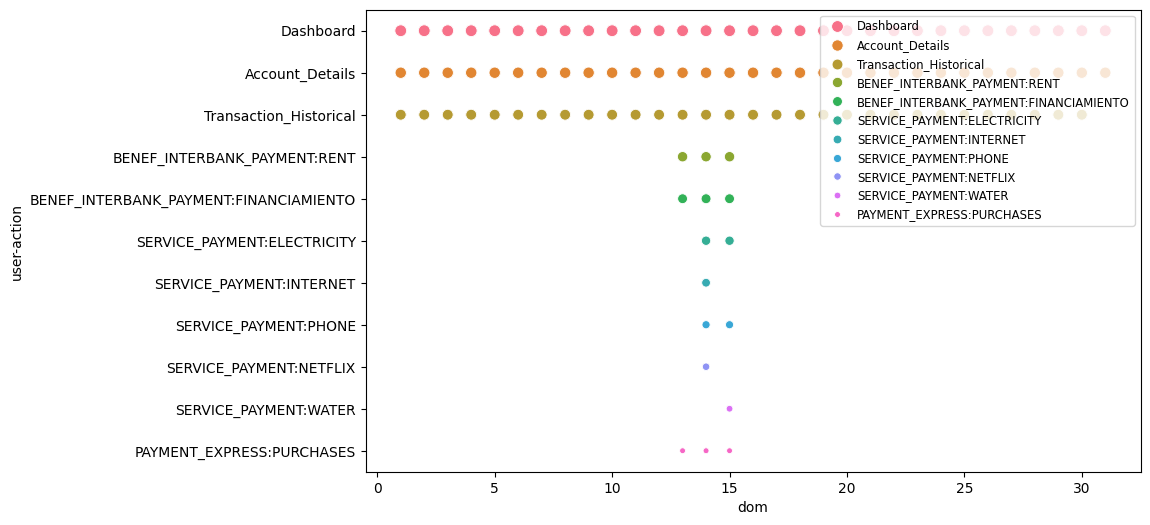

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df[:2000], x='dom', y='user-action', size='user-action', hue='user-action', ax=ax)
plt.legend(loc="upper right", fontsize='small', title_fontsize='medium')
plt.show()

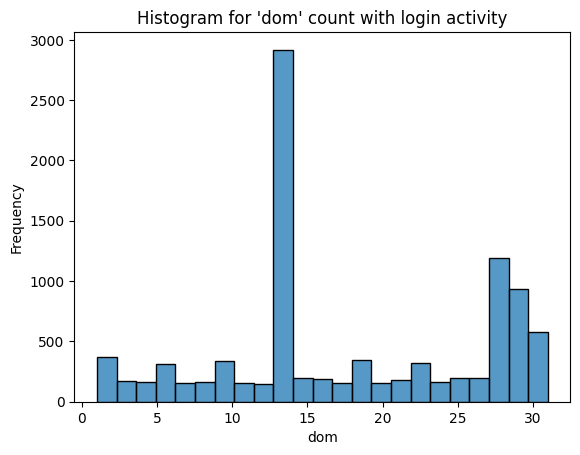

In [29]:
sns.histplot(df, x="dom")
plt.title("Histogram for 'dom' count with login activity")
plt.xlabel("dom")
plt.ylabel("Frequency")
plt.show()

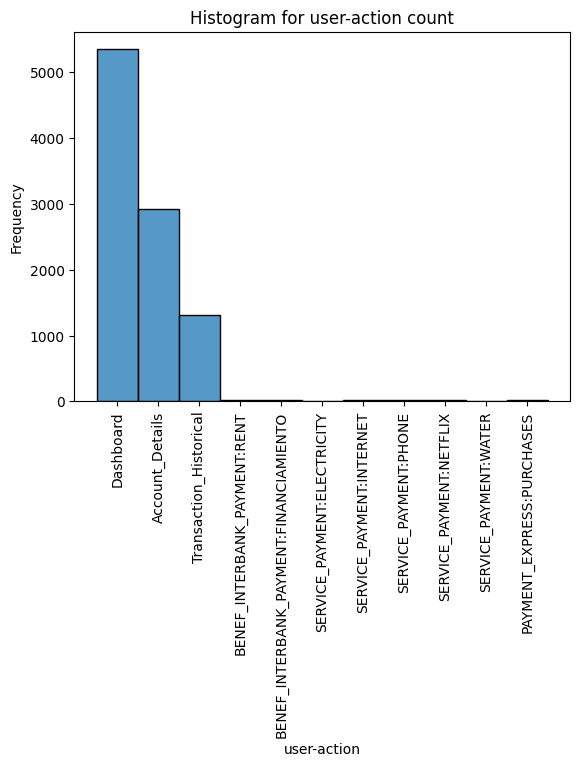

In [30]:
sns.histplot(df, x="user-action")
plt.title("Histogram for user-action count")
plt.xlabel("user-action")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

In [31]:
#Calculate transition probabilities from current user-action to next-action
action_labels = np.unique(df['user-action'])
dim = action_labels.shape[0]
transition_probabilities = np.zeros((dim, dim))
user_actions_combinations = list(itertools.combinations_with_replacement(action_labels, 2))
#transition_probabilities = []
#transition_probabilities = np.zeros(())
total_samples = df.shape[0]
for current_action, next_action in user_actions_combinations:
    count = df[(df['user-action']==current_action) & (df['next-action']==next_action)].shape[0]
    x = np.where(action_labels==current_action)[0][0]
    y = np.where(action_labels==next_action)[0][0]
    transition_probabilities[x, y] = count/total_samples
    #transition_probabilities.append(count/total_samples)
    #print(f"[INFO] Transition probability from {current_action} to {next_action}: {count/total_samples}")

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


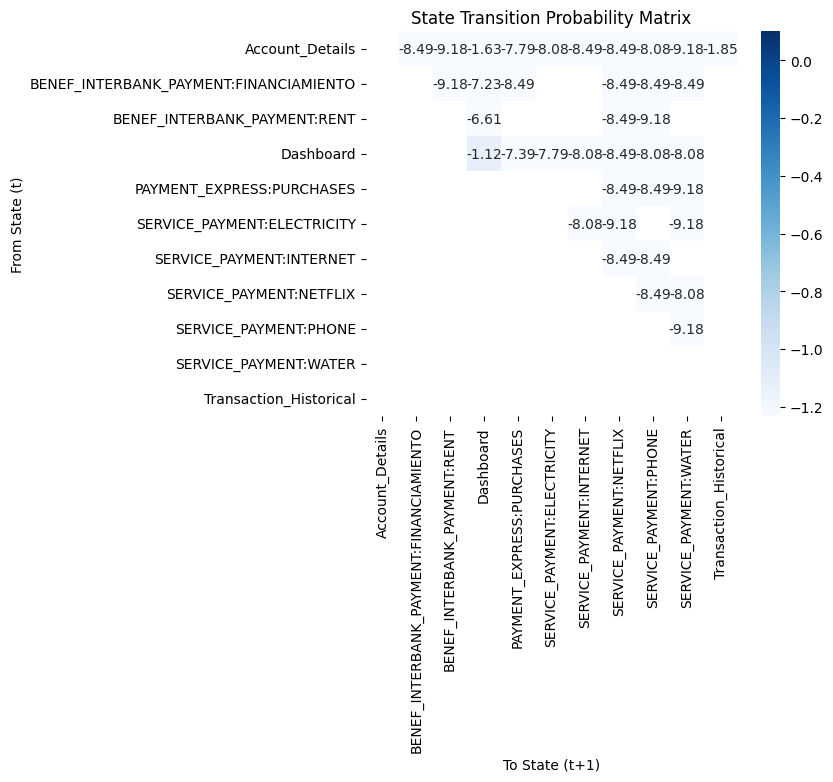

In [32]:
# 2. Convert to DataFrame for easier labeling
df2 = pd.DataFrame(transition_probabilities, index=action_labels, columns=action_labels)

# Translate probabilities between [-inf, inf] with logit function
logit = np.log(df2/(1-df2))

# 3. Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(logit, annot=True, cmap='Blues', fmt='.2f')
plt.title('State Transition Probability Matrix')
plt.ylabel('From State (t)')
plt.xlabel('To State (t+1)')
plt.show()

In [33]:
from google.colab import files

#save and download generated dataset
df.to_csv('banking_dataset.csv', index=False)
files.download('banking_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>